No GPU/TPU found, falling back to CPU. (Set TF_CPP_MIN_LOG_LEVEL=0 and rerun for more info.)


start at 23/10/2023 13:58:48
prng_key = 1697807204
PSGD started ! 
there is an nan in jac_current, stoping the algorithm !       ]

end of the PSGD !
REGULARIZATION PATH TIME: 29.245s
[0]
RESULT SAVED !
[ 2.859e-01  8.097e+01  1.214e+00  1.292e-03  2.674e+01  6.937e-04
  2.385e+00  7.680e-02 -1.099e+00 -5.733e-01 -9.695e-01  2.366e-04
  4.051e-01  5.543e-02  1.008e+00 -5.504e-01  9.846e-01  4.022e-01
  5.858e-01  3.426e-01  8.070e-01 -7.148e-01  4.633e-01  4.398e-02
  5.333e-01 -3.346e-01 -8.883e-01 -2.322e-01  3.765e-01 -2.637e-01
  3.257e-01 -1.365e-01 -4.164e-01 -5.147e-02  2.984e-01  6.947e-01
 -1.934e-01  1.350e-01  1.194e-01  1.473e-01  2.577e-01  4.758e-01
  2.990e-03  2.358e-01 -2.385e-02  7.438e-01 -1.721e-01 -4.764e-01
  3.456e-01  1.635e-01  1.885e-01  8.099e-01  4.120e-01  7.889e-01
 -9.196e-03 -6.191e-02 -1.429e-01 -4.907e-01 -1.765e-01  3.975e-01
  8.475e-01 -6.650e-01  1.284e-01 -6.169e-01 -1.091e-01  1.610e-01
 -6.331e-01  3.661e-05 -3.464e-01 -2.107e-02  3.660e-01  5.3

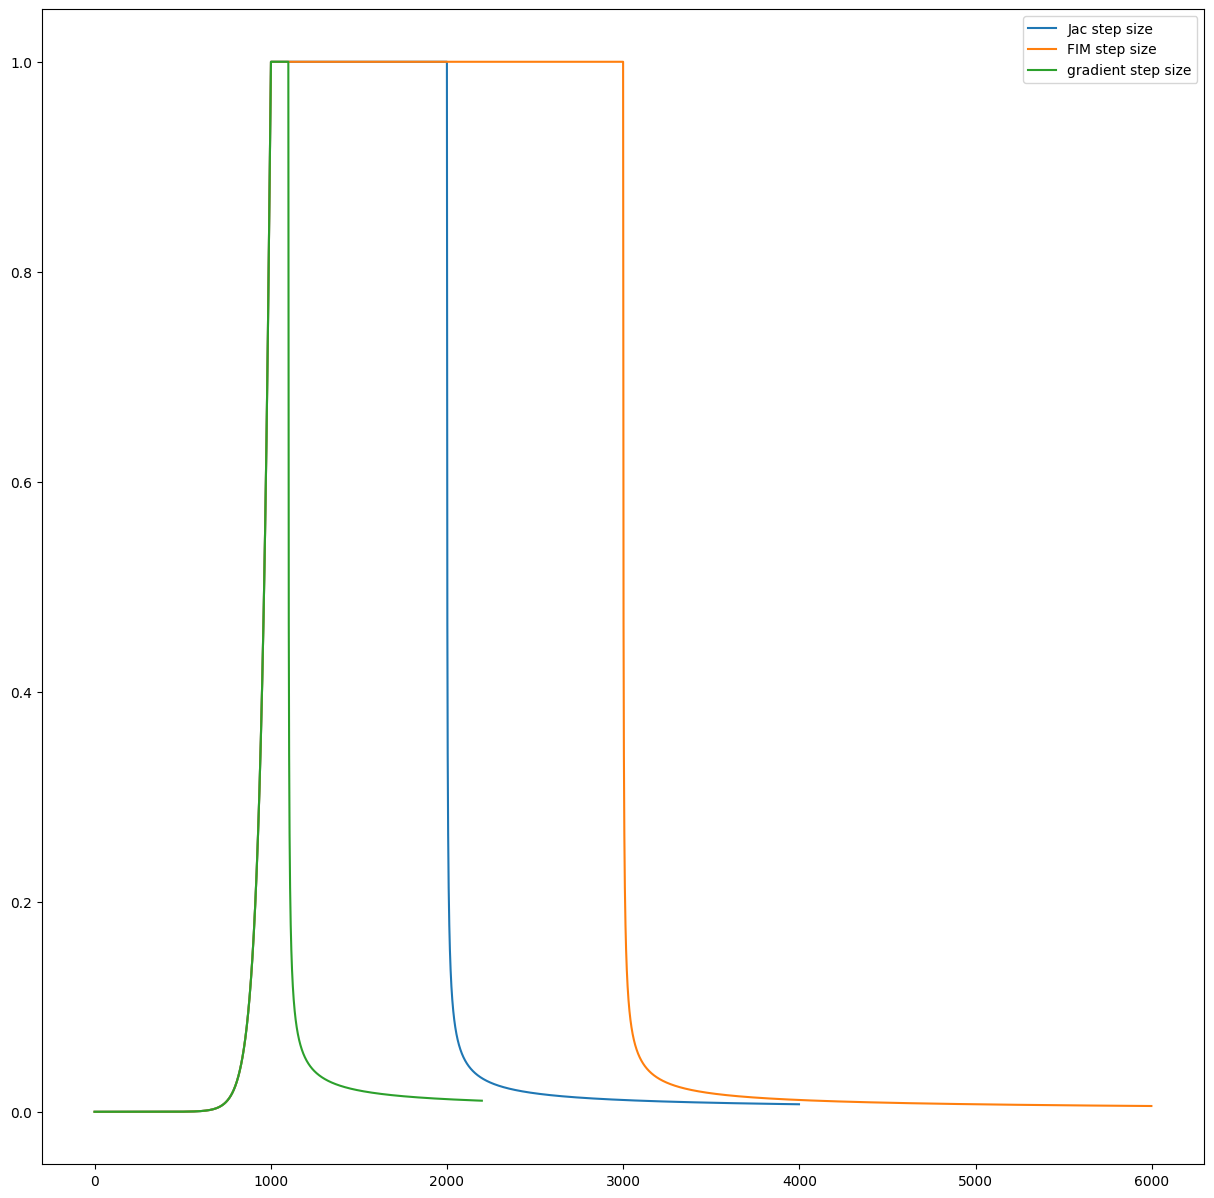

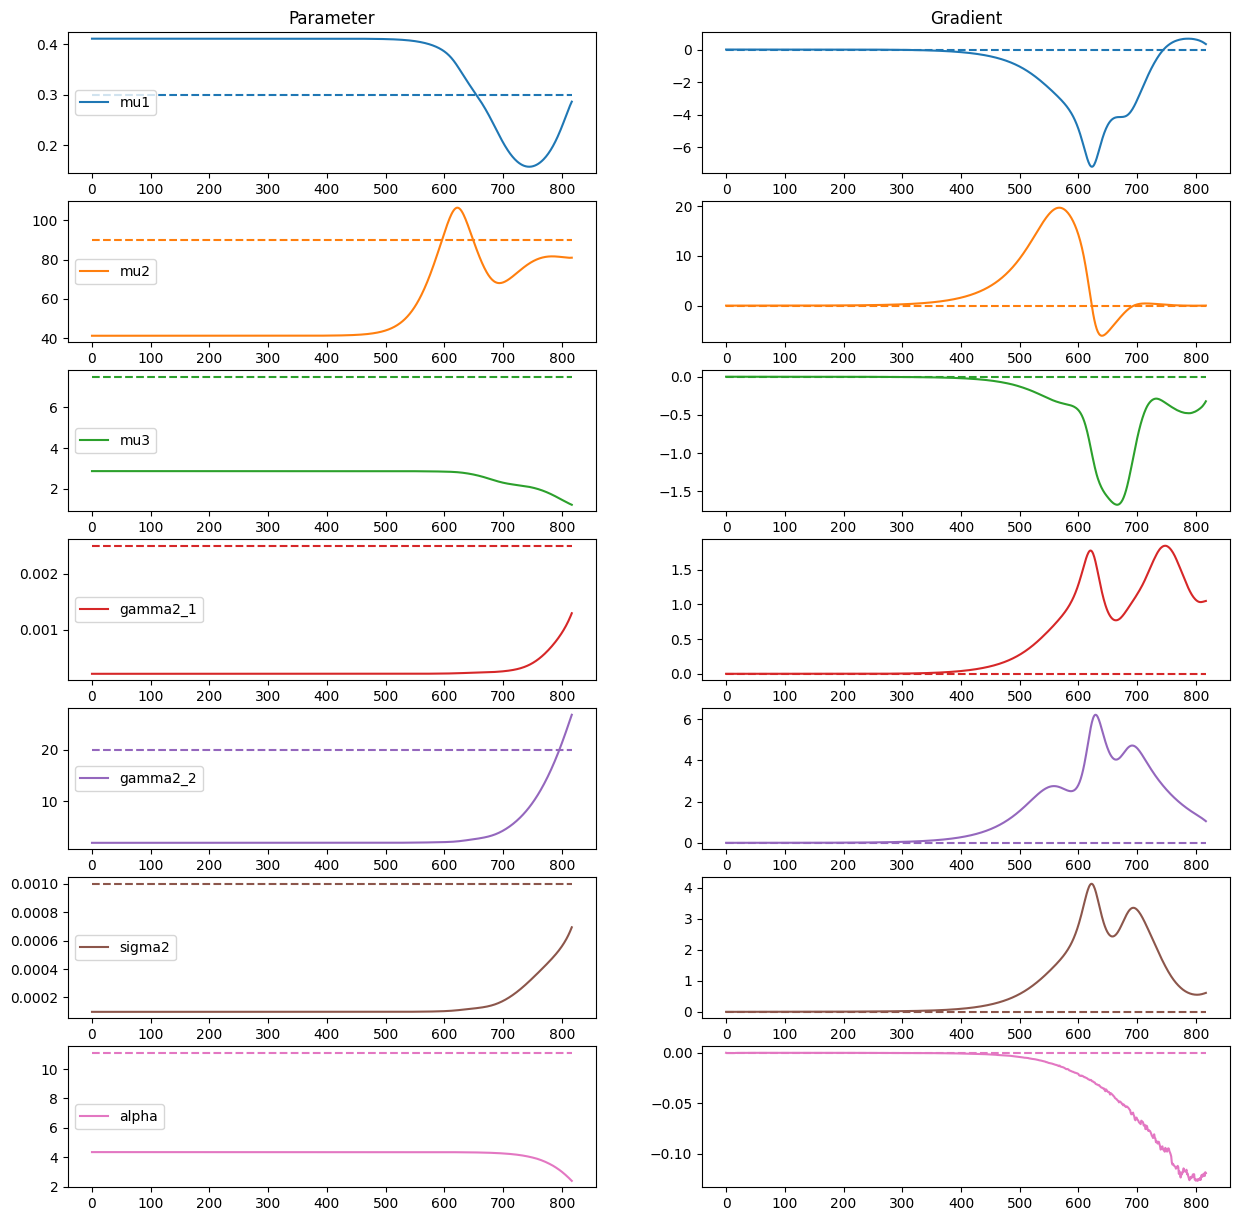

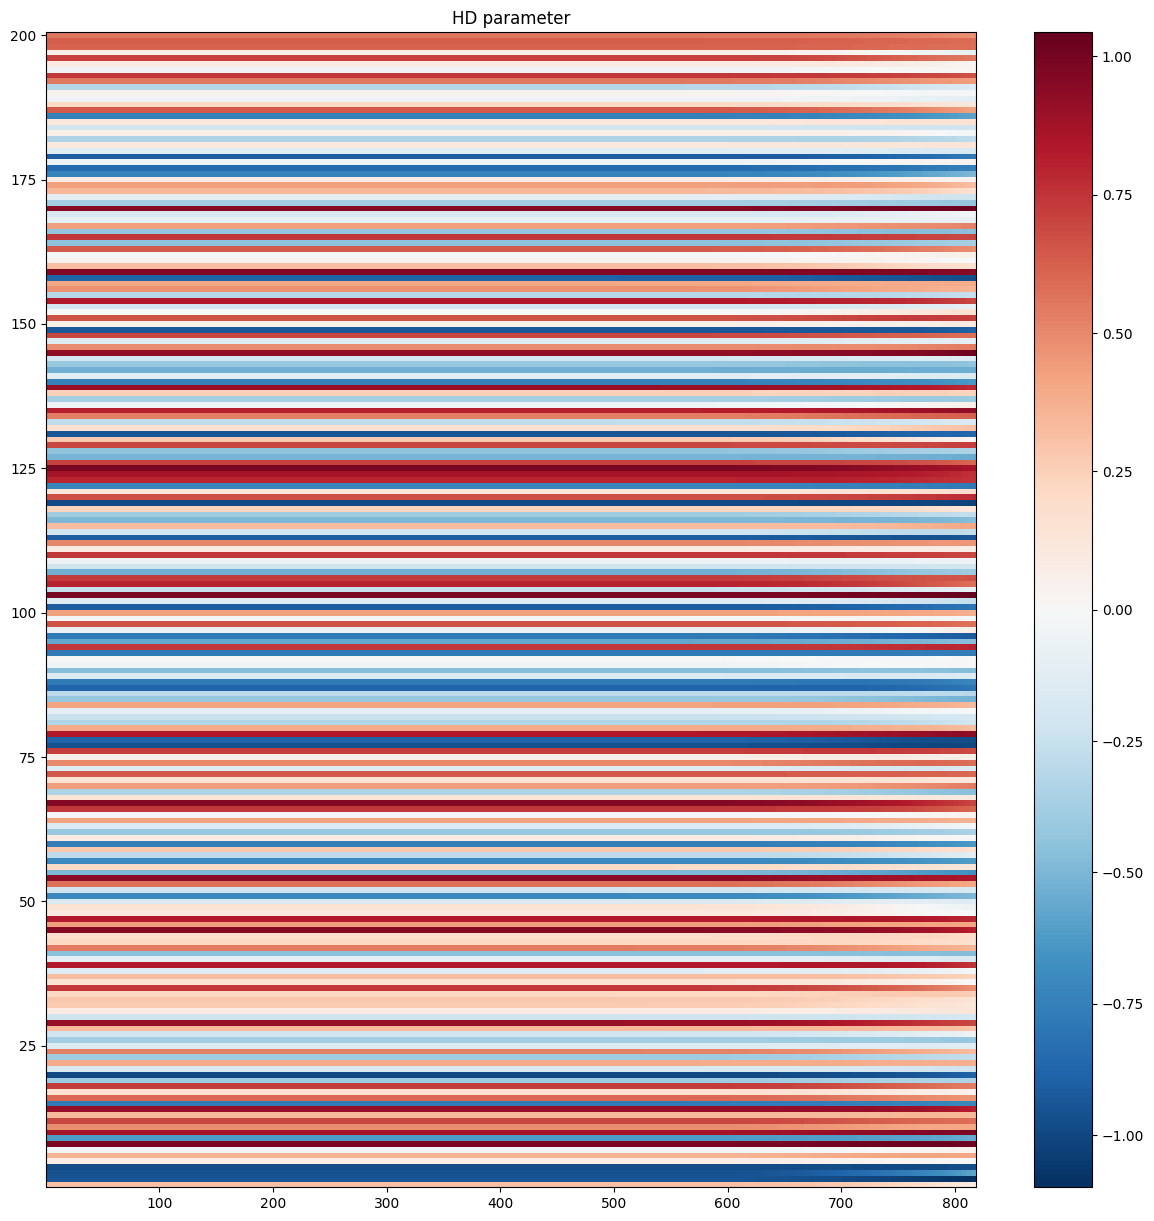

In [1]:
# Create by antoine.caillebotte@inrae.fr
from time import time
from sdg4varselect.miscellaneous import time2string

import sdg4varselect.plot as sdgplt
import pickle
import numpy as np
from datetime import datetime

from sdg4varselect.solver import shrink_support
from one_run import (
    sample,
    estim,
    get_random_params0,
    params_star_weibull,
    params_star_stack,
    N_IND,
    DIM_COV,
    estim_solver,
)
from sdg4varselect.miscellaneous import step_message, bic_final_estim_from_list

from sdg4varselect import jrd, jnp


kwargs_run_GD = {
    "prox_regul": 1.29e-3,
    "proximal_operator": False,
}


def clever_regularization_path(parameters0, path, prng_key, nrep=1, verbatim=False):
    list_res = []
    list_solver = []
    data_set, key = sample(params_star_weibull, prng_key)

    for i in range(len(path)):
        # print(step_message(i, len(path)), end="\r" if not verbatim else "\n")

        kwargs_run_GD["prox_regul"] = path[i]
        kwargs_run_GD["proximal_operator"] = True
        res, solver, key = estim(
            data_set,
            parameters0,
            key,
            niter=2000,
            kwargs_run_GD=kwargs_run_GD,
            verbatim=verbatim,
            activate_fim=True,
            activate_jac_approx=True,
            lr=1e-8,
            # Grad
            plateau_grad=1000,
            plateau_grad_size=100,
            scale_grad=1,
            # Jac
            plateau_jac=1000,
            plateau_jac_size=1000,
            scale_jac=1,
            # Fim
            plateau_fim=1000,
            plateau_fim_size=2000,
            scale_fim=1,
        )

        list_solver.append(solver)
        list_res.append(res)

        # print(f"#beta = {solver.get_number_of_nonzero(p=DIM_COV)}")

        if solver.get_number_of_nonzero(p=DIM_COV) == 0:
            for k in range(len(path) - i - 1):
                # print(
                #     step_message(i + k, len(path)), end="\r" if not verbatim else "\n"
                # )
                list_solver.append(list_solver[-1])
                list_res.append(list_res[-1])

            print(f"break at {path[i]}")
            break

    return list_solver, list_res, key


def final_estim(solver, parameters0, prox_regul, verbatim=False):
    kwargs_run_GD["prox_regul"] = prox_regul
    kwargs_run_GD["proximal_operator"] = False
    p0 = parameters0.copy()

    solver_select, mask_select = shrink_support(solver, "beta", DIM_COV)
    p0["beta"] = jnp.where(mask_select[-DIM_COV:], p0["beta"], 0)
    solver_select.reset_solver()
    solver_select.theta_reals1d = p0

    res, solver_select = estim_solver(
        solver_select,
        niter=2000,
        kwargs_run_GD=kwargs_run_GD,
        verbatim=verbatim,
        activate_fim=True,
        activate_jac_approx=True,
        lr=1e-8,
        # Grad
        plateau_grad=1000,
        plateau_grad_size=100,
        scale_grad=1,
        # Jac
        plateau_jac=1000,
        plateau_jac_size=2000,
        scale_jac=1,
        # Fim
        plateau_fim=1000,
        plateau_fim_size=1000,
        scale_fim=0.9,
    )
    return res, solver_select

    
if __name__ == "__main__":
    # ====================================================== #
    # ================ REGULARIZATION PATH ================= #
    # ====================================================== #
    print(f'start at {datetime.now().strftime("%d/%m/%Y %H:%M:%S")}')

    prng_key = 1697807204  # int(time()) #
    print(f"prng_key = {prng_key}")
    params0, prng_key = get_random_params0(jrd.PRNGKey(prng_key), error=0.2)

    lbd_set = 10 ** jnp.linspace(-2, 0, num=15)
    lbd_set = [lbd_set[0]]

    nrun = 1
    ls, lr = [], []
    for k in range(nrun):
        time_start = time()
        s, r, prng_key = clever_regularization_path(
            params0, lbd_set, prng_key, verbatim=True
        )
        print(f"REGULARIZATION PATH TIME: {time2string(time() - time_start)}")

        ls.append(s)
        lr.append(r)

    # final_res, final_solver = lr[0][0], ls[0][0]

    bic, ebic, theta_reg = bic_final_estim_from_list(
        ls, lr, N_IND, DIM_COV, verbatim=True
    )
    # bic_nJ, theta_reg = bic_final_estim_from_list(
    #     ls, lr, N_IND * 20, DIM_COV, verbatim=True
    # )
    # ============================================ #
    # ================ INFERENCE ================= #
    # ============================================ #
    bic_argmin = np.argmin(bic)
    res_selection = lr[0][bic_argmin]
    solver_selection = ls[0][bic_argmin]
    # lbd_selection = lbd_set[bic_argmin]

    final_res = res_selection
    final_solver = solver_selection
    # final_res, final_solver = final_estim(
    #     solver_selection, params0, lbd_selection, verbatim=True
    # )

    # fig, axs = sdgplt.plot_regularization_path(theta_reg, lbd_set, bic)
    # ax, ax_bic = axs

    # ax_ebic = ax.twinx()
    # ax_ebic.plot(lbd_set, ebic, color="r", linewidth=2, linestyle="--", label="eBIC")
    # id_min = np.nanargmin(ebic)
    # sdgplt.plot_axvline(ax_ebic, lbd_set, ebic, id_min, color="g", msg="min(eBIC)")
    # ax_ebic.legend(loc="upper right")

    # for res in lr[0]:
    #     _, _ = sdgplt.plot_params(
    #         x=res.theta,
    #         x_star=np.array(params_star_stack),
    #         p=DIM_COV,
    #         names=final_solver.params_names,
    #         logscale=False,
    #     )

    # ====================================================== #
    def extract_data(res, solver):
        latent_variables = ls[0][bic_argmin].latent_variables
        for var in latent_variables.values():
            var.likelihood = None

        data = {
            "theta": res.theta,
            "grad_precond": res.grad_precond,
            "likelihood": res.likelihood,
            "theta_diff": res.theta_diff,
            "latent_variables": ls[0][bic_argmin].latent_variables,
            "jac_min": [res.jac[i].min() for i in range(len(res.jac))],
            "jac_max": [res.jac[i].max() for i in range(len(res.jac))],
            "fim_det": [jnp.linalg.det(x) for x in res.fisher_info],
            "fim_vp": np.array([jnp.linalg.eigvalsh(x) for x in res.fisher_info]),
        }
        return data

    data_selection = extract_data(res_selection, ls[0][bic_argmin])
    data_final = extract_data(final_res, final_solver)

    step_size = {
        "jac": final_solver.step_size,
        "fisher": final_solver.step_size_fisher,
        "gradient": final_solver.step_size_grad,
    }

    data = {
        "res_selection": data_selection,
        "res_final": data_final,
        "bic": bic,
        "ebic": ebic,
        "theta_reg": theta_reg,
        "lbd_set": lbd_set,
        "params_names": ls[0][0].params_names,
        "step_size": step_size,
        "DIM_COV": DIM_COV,
        "N_IND": N_IND,
        "params_star_stack": params_star_stack,
    }

    with open("res_selection.pkl", "wb") as f:
        pickle.dump(data, f)

    print("RESULT SAVED !")

    params_names = solver_selection.params_names

    fig = sdgplt.figure()
    solver_selection.step_size.plot(label="Jac step size")
    solver_selection.step_size_fisher.plot(label="FIM step size")
    solver_selection.step_size_grad.plot(label="gradient step size")
    sdgplt.plt.legend()

    _, _ = sdgplt.plot_params_grad(
        res_selection.theta,
        res_selection.grad_precond,
        np.array(params_star_stack),
        p=DIM_COV,
        names=params_names,
        logscale=False,
    )

    _, _ = sdgplt.plot_params_hd(res_selection.theta, p=DIM_COV, location="right")

    print(res_selection.theta[-1][:DIM_COV])

    # =========================#
    # fig = sdgplt.figure()
    # final_solver.step_size.plot(label="Jac step size")
    # final_solver.step_size_fisher.plot(label="FIM step size")
    # final_solver.step_size_grad.plot(label="gradient step size")
    # sdgplt.plt.legend()

    # _, _ = sdgplt.plot_params_grad(
    #     final_res.theta,
    #     final_res.grad_precond,
    #     np.array(params_star_stack),
    #     p=DIM_COV,
    #     names=params_names,
    #     logscale=False,
    # )

    # _, _ = sdgplt.plot_params_hd(final_res.theta, p=DIM_COV, location="right")

    # print(final_res.theta[-1][:DIM_COV])

    print(f'end at {datetime.now().strftime("%d/%m/%Y %H:%M:%S")}')

In [3]:
from model import jac_likelihood

In [5]:
from model import jac_likelihood

jac_likelihood(final_solver.theta_reals1d, **final_solver.likelihood_kwargs
                )

Array([[-11.808,  45.365,   1.77 , ..., -12.133, -30.6  ,  32.126],
       [-14.4  , -54.296,   0.146, ...,   0.322,   0.244,  -0.859],
       [  3.743,   7.257,   1.828, ...,   0.606,   0.251,  -0.071],
       ...,
       [  9.548,  15.146,  -0.429, ...,   9.591, -33.741,   4.722],
       [  0.133,  59.562,  -0.857, ...,  28.879,  17.807, -44.842],
       [-19.823, -61.706,   0.413, ...,  -4.253,   1.231,   0.609]],      dtype=float32)

In [8]:
from model import jac_likelihood
jac_current = jac_likelihood(final_solver.theta_reals1d, **final_solver.likelihood_kwargs
                )

print(jnp.any(jnp.isnan(jac_current)))

jnp.isnan(jac_current).shape

True


(100, 207)

In [9]:
from model import jac_likelihood
jac_current = jac_likelihood(final_solver.theta_reals1d, **final_solver.likelihood_kwargs
                )

print(jnp.any(jnp.isnan(jac_current)))

jnp.where(jnp.isnan(jac_current))

True


(Array([30], dtype=int32), Array([2], dtype=int32))

In [10]:
final_solver.likelihood_kwargs

{'time': Array([ 60.  ,  78.75,  97.5 , 116.25, 135.  ], dtype=float32),
 'Y': Array([[ 0.016,  0.02 ,  0.144,  0.248,  0.17 ],
        [ 0.02 ,  0.066,  0.146,  0.232,  0.311],
        [-0.016,  0.051,  0.186,  0.354,  0.418],
        ...,
        [ 0.016,  0.08 ,  0.36 ,  0.315,  0.366],
        [ 0.023,  0.022,  0.196,  0.335,  0.257],
        [ 0.024,  0.031,  0.154,  0.171,  0.189]], dtype=float32),
 'phi1': array([0.216, 0.2  , 0.308, 0.334, 0.294, 0.26 , 0.248, 0.206, 0.293,
        0.223, 0.338, 0.328, 0.334, 0.178, 0.242, 0.18 , 0.239, 0.136,
        0.193, 0.16 , 0.339, 0.275, 0.203, 0.123, 0.189, 0.249, 0.271,
        0.245, 0.286, 0.27 , 0.213, 0.214, 0.195, 0.26 , 0.308, 0.271,
        0.239, 0.291, 0.318, 0.287, 0.28 , 0.272, 0.326, 0.265, 0.258,
        0.31 , 0.272, 0.373, 0.225, 0.33 , 0.269, 0.279, 0.252, 0.271,
        0.243, 0.172, 0.227, 0.183, 0.239, 0.252, 0.21 , 0.185, 0.216,
        0.274, 0.298, 0.188, 0.292, 0.254, 0.296, 0.32 , 0.248, 0.284,
        0.219, 0

In [11]:
final_solver.theta_reals1d

Array([-0.26 ,  0.81 , -2.047, ...,  0.579,  0.585,  0.475], dtype=float32)

In [14]:
jnp.set_printoptions(threshold=1000)

In [16]:
final_solver.theta_reals1d

Array([-2.595e-01,  8.097e-01, -2.047e+00,  9.708e-01,  2.602e+00,
        1.147e-03,  2.385e-01,  7.680e-02, -1.099e+00, -5.733e-01,
       -9.695e-01,  2.366e-04,  4.051e-01,  5.543e-02,  1.008e+00,
       -5.504e-01,  9.846e-01,  4.022e-01,  5.858e-01,  3.426e-01,
        8.070e-01, -7.148e-01,  4.633e-01,  4.398e-02,  5.333e-01,
       -3.346e-01, -8.883e-01, -2.322e-01,  3.765e-01, -2.637e-01,
        3.257e-01, -1.365e-01, -4.164e-01, -5.147e-02,  2.984e-01,
        6.947e-01, -1.934e-01,  1.350e-01,  1.194e-01,  1.473e-01,
        2.577e-01,  4.758e-01,  2.990e-03,  2.358e-01, -2.385e-02,
        7.438e-01, -1.721e-01, -4.764e-01,  3.456e-01,  1.635e-01,
        1.885e-01,  8.099e-01,  4.120e-01,  7.889e-01, -9.196e-03,
       -6.191e-02, -1.429e-01, -4.907e-01, -1.765e-01,  3.975e-01,
        8.475e-01, -6.650e-01,  1.284e-01, -6.169e-01, -1.091e-01,
        1.610e-01, -6.331e-01,  3.661e-05, -3.464e-01, -2.107e-02,
        3.660e-01,  5.353e-02,  6.025e-01,  6.995e-01,  9.780e

In [17]:
jnp.where(final_solver.theta_reals1d==0)

(Array([ 98, 105], dtype=int32),)

In [19]:
from model import likelihood_array
likelihood_array(final_solver.theta_reals1d, **final_solver.likelihood_kwargs
                )

Array([-4.302e+01, -2.339e+01, -1.341e+01, -2.024e+01,  9.105e+00,
        2.705e+00,  8.313e+00, -4.423e+01,  2.779e+00, -3.590e+01,
       -7.249e+01, -1.082e+00, -8.870e+00, -4.445e+01, -1.672e+01,
       -2.166e+00,  5.237e+00, -1.281e+01, -7.504e+00, -2.720e+01,
        7.153e+00, -1.150e+00, -5.193e+00, -2.725e+01, -2.219e+01,
        3.645e-02,  6.558e+00, -4.530e+01, -4.721e+01, -5.641e+01,
       -8.882e+01,  3.924e+00, -1.778e+01, -1.486e+01,  7.878e-01,
       -1.249e+01,  1.300e+00,  4.777e+00, -4.032e+00, -4.569e+00,
       -7.532e-01, -1.530e+01,  7.699e+00,  3.821e+00, -6.260e+01,
        8.411e-01,  2.256e+00, -2.962e+01,  2.539e+00, -3.946e+01,
        9.958e-01,  4.361e+00, -1.159e+01, -1.683e+01,  5.473e+00,
       -2.017e+01, -3.543e+01, -1.387e+01,  7.312e+00, -1.453e+00,
       -3.433e+01,  4.557e+00, -2.123e+01,  1.056e+00, -2.499e+00,
       -1.213e+01,  3.295e+00, -2.552e+00,  1.002e+01, -4.785e+00,
       -3.177e+00, -2.150e+01, -8.905e-01, -2.301e+01, -4.178e

In [21]:
from sdg4varselect import jacfwd, jit
from model import gaussian_prior
from functools import partial

@partial(
    jit,
    static_argnums=(1),
)
def latent_prior(theta_reals1d, parametrization, **kwargs):
    params = parametrization.reals1d_to_params(theta_reals1d)

    return( gaussian_prior(
        kwargs["phi1"],
        params.mu1,
        params.gamma2_1,
    ) + gaussian_prior(
        kwargs["phi2"],
        params.mu2,
        params.gamma2_2,
    )
    )

latent_prior_jac = jacfwd(latent_prior)

latent_prior_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)

Array([[-11.808,  45.365,  -0.   , ...,  -0.   ,  -0.   ,  -0.   ],
       [-14.4  , -54.296,  -0.   , ...,  -0.   ,  -0.   ,  -0.   ],
       [  3.743,   7.257,  -0.   , ...,  -0.   ,  -0.   ,  -0.   ],
       ...,
       [  9.548,  15.146,  -0.   , ...,  -0.   ,  -0.   ,  -0.   ],
       [  0.133,  59.562,  -0.   , ...,  -0.   ,  -0.   ,  -0.   ],
       [-19.823, -61.706,  -0.   , ...,  -0.   ,  -0.   ,  -0.   ]],      dtype=float32)

In [22]:
from sdg4varselect import jacfwd, jit
from model import gaussian_prior
from functools import partial

@partial(
    jit,
    static_argnums=(1),
)
def latent_prior(theta_reals1d, parametrization, **kwargs):
    params = parametrization.reals1d_to_params(theta_reals1d)

    return( gaussian_prior(
        kwargs["phi1"],
        params.mu1,
        params.gamma2_1,
    ) + gaussian_prior(
        kwargs["phi2"],
        params.mu2,
        params.gamma2_2,
    )
    )

latent_prior_jac = jacfwd(latent_prior)

res = latent_prior_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))


Array(False, dtype=bool)

In [27]:
from model import likelihood_nlmem_without_prior

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return likelihood_nlmem_without_prior(params, **kwargs)

nlmem_jac = jacfwd(test)

res = nlmem_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(False, dtype=bool)

In [28]:
from model import likelihood_survival_without_prior

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return likelihood_survival_without_prior(params, **kwargs)

survival_jac = jacfwd(test)

res = survival_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(True, dtype=bool)

In [30]:
from model import log_hazard
@jit
def survival_test(
    params, phi1, phi2, T, cov, **kwargs
) -> jnp.ndarray:
    """return likelihood without the gaussian prior"""
    (N,) = T.shape
    (p,) = params.beta.shape
    assert T.shape == (N,)
    assert phi1.shape == (N,)
    assert phi2.shape == (N,)
    assert cov.shape == (N, p)
    # ===================== #
    # === survival_likelihood === #
    # ===================== #
    # survival_likelihood = log(survival_fct) + log(hazard_fct)

    # ================= survival_fct ================= #
    # log_survival_fct = - int_0^T hazard(s) ds
    time_s = jnp.linspace(0, T, num=100)[1:].T

    hazard_kwargs = {
        "time": time_s,
        "phi1": phi1,
        "phi2": phi2,
        "mu3": params.mu3,
        "a": 80,  # params_star_weibull.a,
        "b": 35,  # params_star_weibull.b,
        "alpha": params.alpha,
        "beta": params.beta,
        "cov": cov,
    }
    log_hazard_value = log_hazard(**hazard_kwargs)
    assert time_s.shape == log_hazard_value.shape

    log_survival_fct = -jnp.trapz(jnp.exp(log_hazard_value), time_s)
    assert log_survival_fct.shape == (N,)
    # =============== end survival_fct =============== #
    return log_survival_fct

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return survival_test(params, **kwargs)

survival_jac = jacfwd(test)

res = survival_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(True, dtype=bool)

In [32]:
from model import log_hazard
@jit
def survival_test(
    params, phi1, phi2, T, cov, **kwargs
) -> jnp.ndarray:
    """return likelihood without the gaussian prior"""
    (N,) = T.shape
    (p,) = params.beta.shape
    assert T.shape == (N,)
    assert phi1.shape == (N,)
    assert phi2.shape == (N,)
    assert cov.shape == (N, p)
    # ===================== #
    # === survival_likelihood === #
    # ===================== #
    # survival_likelihood = log(survival_fct) + log(hazard_fct)

    # ================= survival_fct ================= #
    # log_survival_fct = - int_0^T hazard(s) ds
    time_s = jnp.linspace(0, T, num=100)[1:].T

    hazard_kwargs = {
        "time": time_s,
        "phi1": phi1,
        "phi2": phi2,
        "mu3": params.mu3,
        "a": 80,  # params_star_weibull.a,
        "b": 35,  # params_star_weibull.b,
        "alpha": params.alpha,
        "beta": params.beta,
        "cov": cov,
    }
    log_hazard_value = log_hazard(**hazard_kwargs)
    assert time_s.shape == log_hazard_value.shape

    # ================= hazard_fct ================= #
    # log_hazard_fct = log(b*a^-b * T^{b-1}) + beta^T U + alpha*m(T, phi_g)
    # Comme time_s[:,-1] == T, on peut faire :
    log_hazard_fct = log_hazard_value[:, -1]
    assert log_hazard_fct.shape == (N,)
    # =============== end hazard_fct =============== #

    return log_hazard_fct

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return survival_test(params, **kwargs)

survival_jac = jacfwd(test)

res = survival_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(False, dtype=bool)

In [33]:
from model import log_hazard
@jit
def survival_test(
    params, phi1, phi2, T, cov, **kwargs
) -> jnp.ndarray:
    """return likelihood without the gaussian prior"""
    (N,) = T.shape
    (p,) = params.beta.shape
    assert T.shape == (N,)
    assert phi1.shape == (N,)
    assert phi2.shape == (N,)
    assert cov.shape == (N, p)
    # ===================== #
    # === survival_likelihood === #
    # ===================== #
    # survival_likelihood = log(survival_fct) + log(hazard_fct)

    # ================= survival_fct ================= #
    # log_survival_fct = - int_0^T hazard(s) ds
    time_s = jnp.linspace(0, T, num=100)[1:].T

    hazard_kwargs = {
        "time": time_s,
        "phi1": phi1,
        "phi2": phi2,
        "mu3": params.mu3,
        "a": 80,  # params_star_weibull.a,
        "b": 35,  # params_star_weibull.b,
        "alpha": params.alpha,
        "beta": params.beta,
        "cov": cov,
    }
    log_hazard_value = log_hazard(**hazard_kwargs)
    assert time_s.shape == log_hazard_value.shape

    log_survival_fct = -jnp.trapz(jnp.exp(log_hazard_value), time_s)
    assert log_survival_fct.shape == (N,)
    # =============== end survival_fct =============== #
    return log_survival_fct

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return survival_test(params, **kwargs)

survival_jac = jacfwd(test)

res = survival_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(True, dtype=bool)

In [39]:
from model import log_hazard
@jit
def survival_test(
    params, phi1, phi2, T, cov, **kwargs
) -> jnp.ndarray:
    """return likelihood without the gaussian prior"""
    (N,) = T.shape
    (p,) = params.beta.shape
    assert T.shape == (N,)
    assert phi1.shape == (N,)
    assert phi2.shape == (N,)
    assert cov.shape == (N, p)
    # ===================== #
    # === survival_likelihood === #
    # ===================== #
    # survival_likelihood = log(survival_fct) + log(hazard_fct)

    # ================= survival_fct ================= #
    # log_survival_fct = - int_0^T hazard(s) ds
    time_s = jnp.linspace(0, T, num=100)[1:].T

    hazard_kwargs = {
        "time": time_s,
        "phi1": phi1,
        "phi2": phi2,
        "mu3": params.mu3,
        "a": 80,  # params_star_weibull.a,
        "b": 35,  # params_star_weibull.b,
        "alpha": params.alpha,
        "beta": params.beta,
        "cov": cov,
    }
    log_hazard_value = log_hazard(**hazard_kwargs)
    assert time_s.shape == log_hazard_value.shape

    log_survival_fct = -jnp.trapz(jnp.exp(log_hazard_value), time_s)
    assert log_survival_fct.shape == (N,)
    # =============== end survival_fct =============== #
    return log_survival_fct

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return survival_test(params, **kwargs)

survival_jac = jacfwd(test)

res = survival_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(True, dtype=bool)

In [40]:
from model import log_hazard
@jit
def survival_test(
    params, phi1, phi2, T, cov, **kwargs
) -> jnp.ndarray:
    """return likelihood without the gaussian prior"""
    (N,) = T.shape
    (p,) = params.beta.shape
    assert T.shape == (N,)
    assert phi1.shape == (N,)
    assert phi2.shape == (N,)
    assert cov.shape == (N, p)
    # ===================== #
    # === survival_likelihood === #
    # ===================== #
    # survival_likelihood = log(survival_fct) + log(hazard_fct)

    # ================= survival_fct ================= #
    # log_survival_fct = - int_0^T hazard(s) ds
    time_s = jnp.linspace(0, T, num=100)[1:].T

    hazard_kwargs = {
        "time": time_s,
        "phi1": phi1,
        "phi2": phi2,
        "mu3": params.mu3,
        "a": 80,  # params_star_weibull.a,
        "b": 35,  # params_star_weibull.b,
        "alpha": params.alpha,
        "beta": params.beta,
        "cov": cov,
    }
    log_hazard_value = log_hazard(**hazard_kwargs)
    assert time_s.shape == log_hazard_value.shape

    return log_hazard_value

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return survival_test(params, **kwargs)

survival_jac = jacfwd(test)

res = survival_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(True, dtype=bool)

In [43]:
from model import log_hazard
@jit
def survival_test(
    params, phi1, phi2, T, cov, **kwargs
) -> jnp.ndarray:
    """return likelihood without the gaussian prior"""
    (N,) = T.shape
    (p,) = params.beta.shape
    assert T.shape == (N,)
    assert phi1.shape == (N,)
    assert phi2.shape == (N,)
    assert cov.shape == (N, p)
    # ===================== #
    # === survival_likelihood === #
    # ===================== #
    # survival_likelihood = log(survival_fct) + log(hazard_fct)

    # ================= survival_fct ================= #
    # log_survival_fct = - int_0^T hazard(s) ds
    time_s = jnp.linspace(0, T, num=100)[1:].T

    hazard_kwargs = {
        "time": time_s,
        "phi1": phi1,
        "phi2": phi2,
        "mu3": params.mu3,
        "a": 80,  # params_star_weibull.a,
        "b": 35,  # params_star_weibull.b,
        "alpha": params.alpha,
        "beta": params.beta,
        "cov": cov,
    }
    logistic_value = logistic_curve(time_s, phi1, phi2, jnp.array([hazard_kwargs['mu3']]))

    return logistic_value

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return survival_test(params, **kwargs)

survival_jac = jacfwd(test)

res = survival_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(True, dtype=bool)

In [48]:
final_solver.likelihood_kwargs['phi1']

array([0.216, 0.2  , 0.308, 0.334, 0.294, 0.26 , 0.248, 0.206, 0.293,
       0.223, 0.338, 0.328, 0.334, 0.178, 0.242, 0.18 , 0.239, 0.136,
       0.193, 0.16 , 0.339, 0.275, 0.203, 0.123, 0.189, 0.249, 0.271,
       0.245, 0.286, 0.27 , 0.213, 0.214, 0.195, 0.26 , 0.308, 0.271,
       0.239, 0.291, 0.318, 0.287, 0.28 , 0.272, 0.326, 0.265, 0.258,
       0.31 , 0.272, 0.373, 0.225, 0.33 , 0.269, 0.279, 0.252, 0.271,
       0.243, 0.172, 0.227, 0.183, 0.239, 0.252, 0.21 , 0.185, 0.216,
       0.274, 0.298, 0.188, 0.292, 0.254, 0.296, 0.32 , 0.248, 0.284,
       0.219, 0.238, 0.211, 0.253, 0.163, 0.319, 0.21 , 0.182, 0.302,
       0.264, 0.265, 0.332, 0.293, 0.259, 0.271, 0.28 , 0.162, 0.226,
       0.1  , 0.252, 0.145, 0.197, 0.342, 0.229, 0.298, 0.343, 0.287,
       0.168])

In [49]:
final_solver.likelihood_kwargs['phi2']

array([ 93.096,  66.449,  82.907,  82.173,  79.857,  85.724,  79.797,
        68.193,  80.577,  92.978,  66.249,  81.713,  80.956,  80.515,
        68.716,  83.505,  83.968,  67.131,  67.107,  68.162,  79.284,
        82.815,  76.112,  71.687,  66.044,  83.655,  79.906,  68.955,
        62.656,  65.317, 103.57 ,  83.098,  65.167,  85.023,  83.864,
        82.367,  80.886,  81.922,  80.131,  82.82 ,  83.721,  81.613,
        78.998,  80.595,  65.893,  82.746,  79.468,  84.962,  82.725,
        93.415,  80.641,  80.188,  68.169,  83.723,  81.865,  63.895,
        93.019,  72.793,  79.288,  83.197,  85.194,  83.96 ,  68.461,
        81.074,  81.965,  72.334,  82.53 ,  68.667,  79.131,  82.034,
        80.817,  82.675,  79.405,  66.906,  80.874,  83.438,  63.749,
        80.865,  83.471,  59.744,  80.963,  82.748,  84.019,  82.838,
        80.406,  79.719,  82.537,  63.133,  58.74 ,  70.496,  68.163,
        80.306,  66.439,  65.151,  80.556,  86.363,  79.837,  85.016,
        96.891,  64.

In [50]:
final_solver.likelihood_kwargs['parametrization'].reals1d_to_params(final_solver.theta_reals1d).mu3

Array(1.214, dtype=float32)

In [51]:
final_solver.likelihood_kwargs['T']

Array([78.635, 75.998, 75.946, 77.733, 79.354, 76.235, 78.935, 89.321,
       76.716, 85.046, 77.367, 78.227, 77.228, 79.655, 66.874, 85.212,
       71.864, 85.176, 77.104, 87.338, 74.093, 70.706, 75.585, 79.29 ,
       83.229, 75.548, 82.949, 86.453, 85.888, 79.092, 90.797, 79.718,
       83.21 , 83.191, 79.831, 79.522, 70.349, 76.992, 80.453, 73.599,
       67.232, 79.586, 72.946, 80.666, 72.828, 73.395, 78.757, 76.189,
       88.698, 87.878, 76.968, 70.159, 75.234, 81.661, 69.204, 76.127,
       80.496, 79.102, 81.865, 73.667, 82.569, 76.509, 80.329, 75.77 ,
       91.001, 76.095, 70.712, 72.604, 71.73 , 75.076, 80.156, 80.494,
       79.031, 81.089, 70.331, 77.108, 76.911, 78.604, 79.372, 65.633,
       74.487, 76.528, 77.184, 68.545, 77.516, 78.61 , 79.321, 63.102,
       88.23 , 73.269, 75.76 , 88.462, 71.434, 77.289, 70.799, 76.699,
       77.567, 81.106, 87.726, 78.222], dtype=float32)

In [52]:
T = final_solver.likelihood_kwargs['T']
jnp.linspace(0, T, num=100)[1:].T

Array([[ 0.794,  1.589,  2.383, ..., 77.046, 77.841, 78.635],
       [ 0.768,  1.535,  2.303, ..., 74.463, 75.23 , 75.998],
       [ 0.767,  1.534,  2.301, ..., 74.412, 75.179, 75.946],
       ...,
       [ 0.819,  1.639,  2.458, ..., 79.468, 80.287, 81.106],
       [ 0.886,  1.772,  2.658, ..., 85.954, 86.84 , 87.726],
       [ 0.79 ,  1.58 ,  2.37 , ..., 76.642, 77.432, 78.222]],      dtype=float32)

In [53]:
from model import log_hazard
@jit
def survival_test(
    params, phi1, phi2, T, cov, **kwargs
) -> jnp.ndarray:
    """return likelihood without the gaussian prior"""
    (N,) = T.shape
    (p,) = params.beta.shape
    assert T.shape == (N,)
    assert phi1.shape == (N,)
    assert phi2.shape == (N,)
    assert cov.shape == (N, p)
    # ===================== #
    # === survival_likelihood === #
    # ===================== #
    # survival_likelihood = log(survival_fct) + log(hazard_fct)

    # ================= survival_fct ================= #
    # log_survival_fct = - int_0^T hazard(s) ds
    time_s = jnp.linspace(0, T, num=100)[1:].T

    hazard_kwargs = {
        "time": time_s,
        "phi1": phi1,
        "phi2": phi2,
        "mu3": params.mu3,
        "a": 80,  # params_star_weibull.a,
        "b": 35,  # params_star_weibull.b,
        "alpha": params.alpha,
        "beta": params.beta,
        "cov": cov,
    }
    logistic_value = logistic_curve(time_s, phi1, phi2, jnp.array([hazard_kwargs['mu3']]))

    return logistic_value

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return survival_test(params, **kwargs)

survival_jac = jacfwd(test)

res = survival_jac(final_solver.theta_reals1d, **final_solver.likelihood_kwargs)
jnp.any(jnp.isnan(res))

Array(True, dtype=bool)

In [90]:
from model import log_hazard
@jit
def survival_test(
    params, phi1, phi2, T, **kwargs
) -> jnp.ndarray:
    """return likelihood without the gaussian prior"""
    (N,) = T.shape
    assert T.shape == (N,)
    assert phi1.shape == (N,)
    assert phi2.shape == (N,)
    
    time_s = jnp.linspace(0, T, num=100)[1:].T
    time_s = time_s[1,0]

    hazard_kwargs = {
        "mu3": params.mu3,
    }
    logistic_value = logistic_curve(time_s, phi1, phi2, jnp.array([hazard_kwargs['mu3']]))

    return logistic_value, time_s

@partial(
    jit,
    static_argnums=(1),
)
def test(theta_reals1d, parametrization, **kwargs):
    """return likelihood"""
    params = parametrization.reals1d_to_params(theta_reals1d)
    return survival_test(params, **kwargs)

survival_jac = jacfwd(test)


kwargs = {'parametrization':final_solver.likelihood_kwargs['parametrization'],
          'Y':final_solver.likelihood_kwargs['Y']}
phi1 = final_solver.likelihood_kwargs['phi1'][30:31]
phi2 = final_solver.likelihood_kwargs['phi2'][30:31]
T = final_solver.likelihood_kwargs['T'][30:31]
cov = final_solver.likelihood_kwargs['cov'][30:31,:]
mu3=final_solver.likelihood_kwargs['parametrization'].reals1d_to_params(final_solver.theta_reals1d).mu3


res,time_s = survival_jac(final_solver.theta_reals1d, phi1=phi1, phi2=phi2, T=T,cov= cov,**kwargs)
print(jnp.where(jnp.isnan(res)))
print(f'phi1 = {phi1}, phi2 = {phi2}, T = {T}, mu3 ={mu3}, time_s ={time_s}')
res

(Array([0], dtype=int32), Array([0], dtype=int32), Array([2], dtype=int32))
phi1 = [0.213], phi2 = [103.57], T = [90.797], mu3 =1.2138522863388062, time_s =[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


Array([[[ 0.,  0., nan,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
          0.,  0.,  0.,  0.,  0., 

In [91]:
103.57/1.2138522863388062

85.32339656613861

In [92]:
jnp.exp(103.57/1.2138522863388062)

Array(1.136e+37, dtype=float32, weak_type=True)